# Deep learning for Computer Vision 

## Pytorch
 + 张量（Tensor）:多维数组
 
    PyTorch 中最基本的数据结构，所有模型的数据（输入、输出、参数）都是用张量来表示的

In [1]:
import torch

scalar = torch.tensor(8.0)
print(scalar.shape)

vector = torch.tensor([1,3,5,8])
print(vector)
print(vector.shape)

matrix = torch.tensor([[1,2,3],[4,5,6]])
print(matrix)
print(matrix.shape)

tensor_3d = torch.tensor([[[1,2],[3,4]],[[5,6],[7,8]]])
print(tensor_3d.shape)

# torch.zeros全0张量 torch.ones全1张量 torch.eye单位矩阵 torch.rand随机张量

torch.Size([])
tensor([1, 3, 5, 8])
torch.Size([4])
tensor([[1, 2, 3],
        [4, 5, 6]])
torch.Size([2, 3])
torch.Size([2, 2, 2])


## 1.图像分类
  机器学习：数据驱动
  收集数据->训练分类器->应用

In [2]:
def train(images,labels):
    # machine learning
    model = {
        'train_images': images,
        'train_labels': labels
    }
    return model
def predict(model,test_images):
    # use model to predict labels
    return test_images

### 最简单的分类方法 K最近邻算法（k-Nearest Neighbor）（KNN）
  将测试集和训练集的每个图像使用一个相似度函数比较并输出相似度最高的对应的标签

  步骤：

  确定**距离度量**：首先，需要定义如何计算数据点之间的距离。最常用的方法是欧几里得距离（即直线距离），其他还有曼哈顿距离、闵可夫斯基距离等。

  选择k值：确定要考察的“邻居”数量，即 k 的值。例如，k=3 意味着我们看最近的3个邻居。

  计算距离：对于一个新的、需要预测的数据点（查询点），计算它与训练数据集中每一个点的距离。
  
  寻找邻居：从所有计算出的距离中，找出距离最近的 k 个点。
  
  投票决定：查看这 k 个邻居的类别标签，进行多数投票。哪一类别的点最多，就将新数据点预测为那个类别。


**解释**：
  
![屏幕截图 2025-09-29 182410.png](<attachment:屏幕截图 2025-09-29 182410.png>)

 1.对距离排序找k近邻 2.用索引在y_train中取值 3.取频次最大的最小标签

计算距离时，np向量化计算（矩阵乘法和广播）相对于Python循环更有效率

使用交叉验证
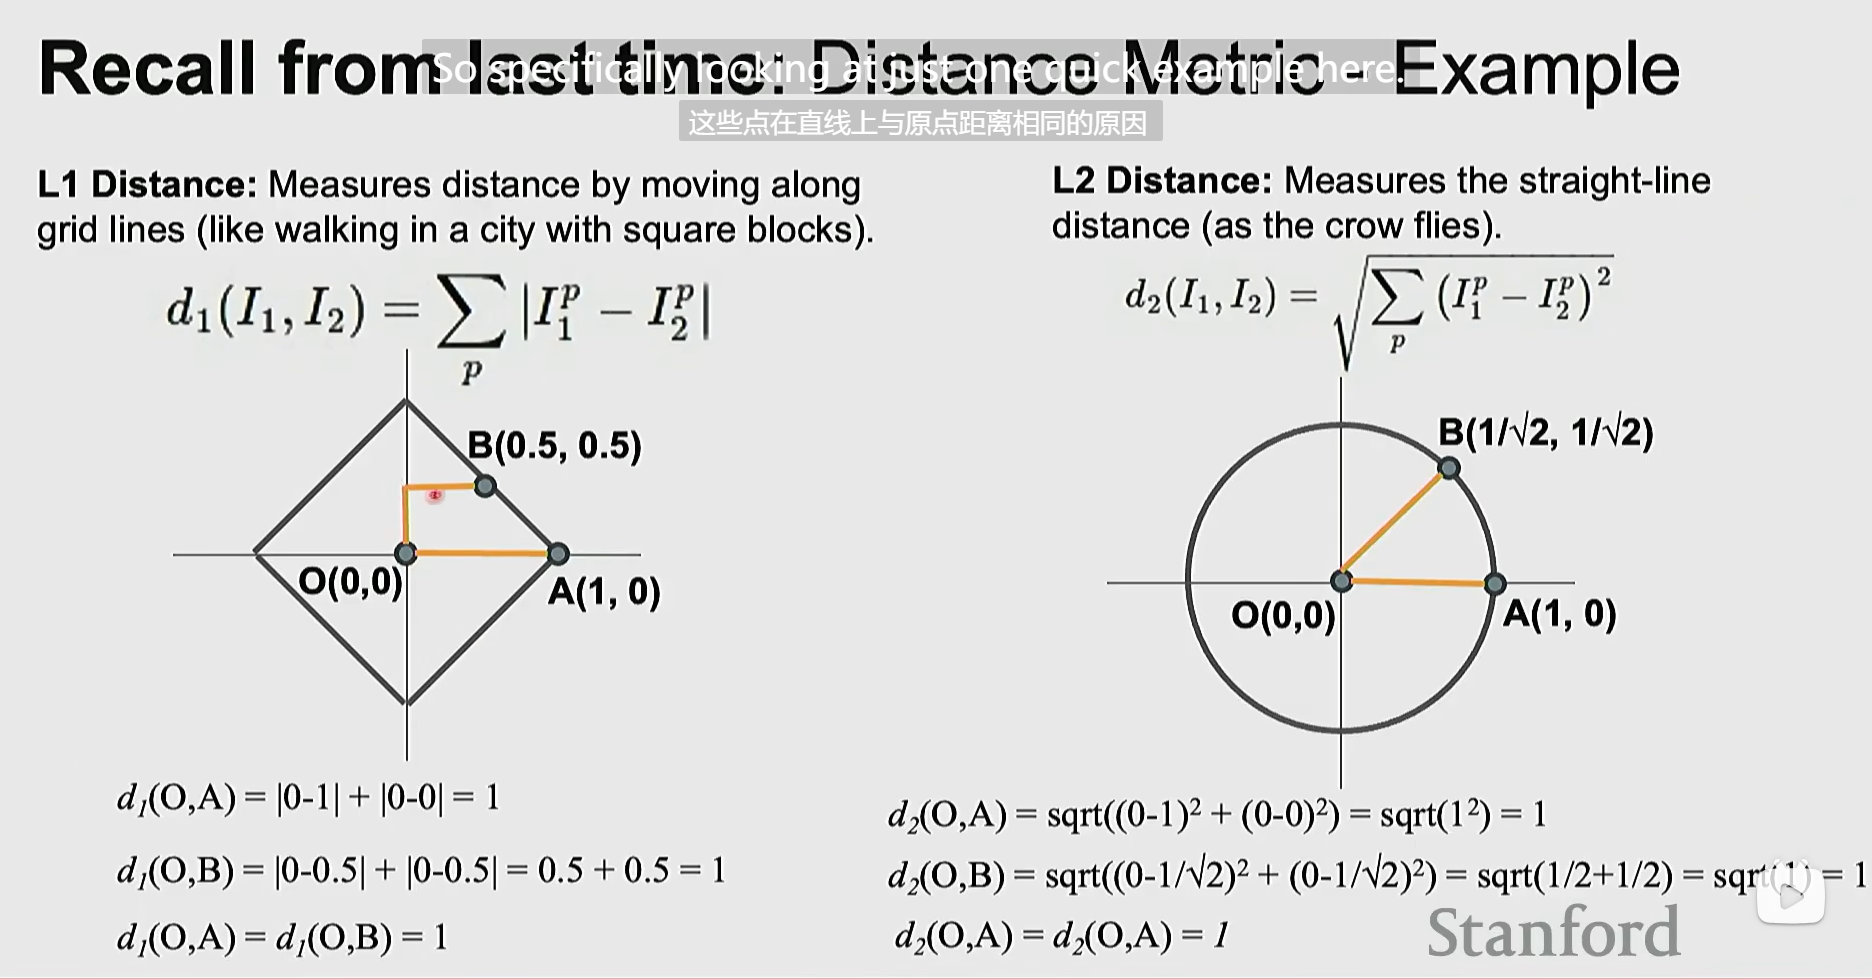

## 线性分类器
 包含两点：评价函数和损失函数，前者用于将原始的数据映射成某一分类的得分情况，后者用于量化预测结果和真实结果的差距 

### 从图像到标签的映射（数据预处理）
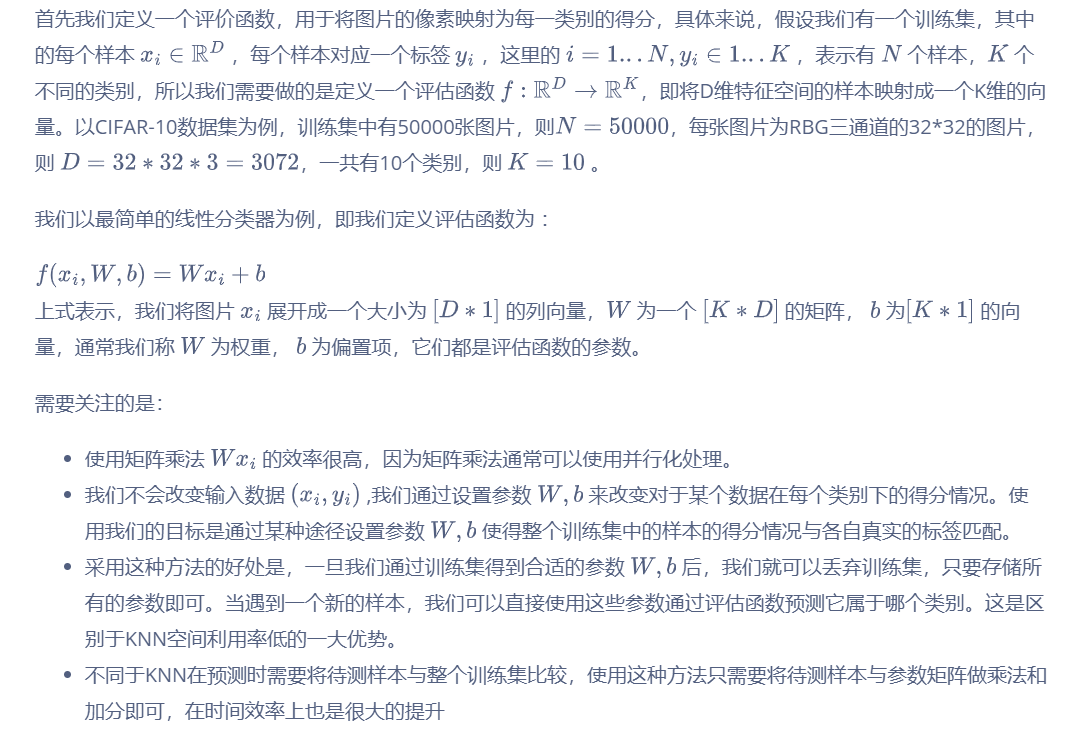
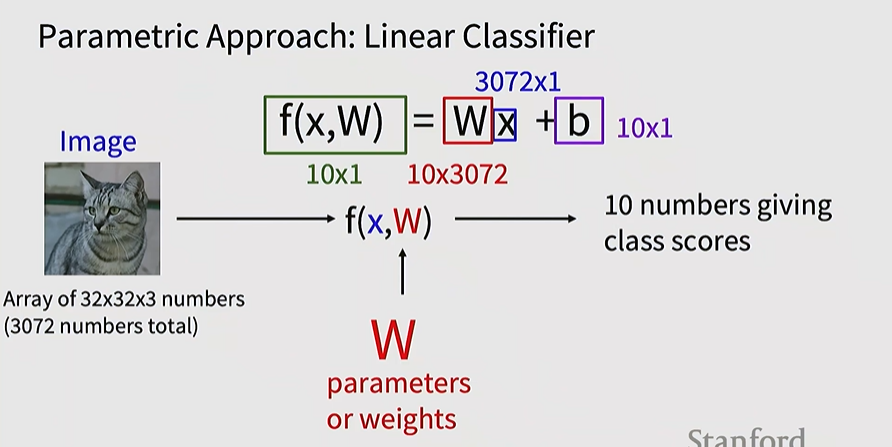

也可这样理解(在实际代码中)：  
- W: 权重矩阵 (D × K)
- X: 输入数据 (N × D)  
- b: 偏置向量 (1 × K)  
这样计算： X * W + b  
(1 × D) * (D × K) + b   ——>  (1 × D+1) * (D+1 × K)

### 线性分类器的解释
#### 直观理解
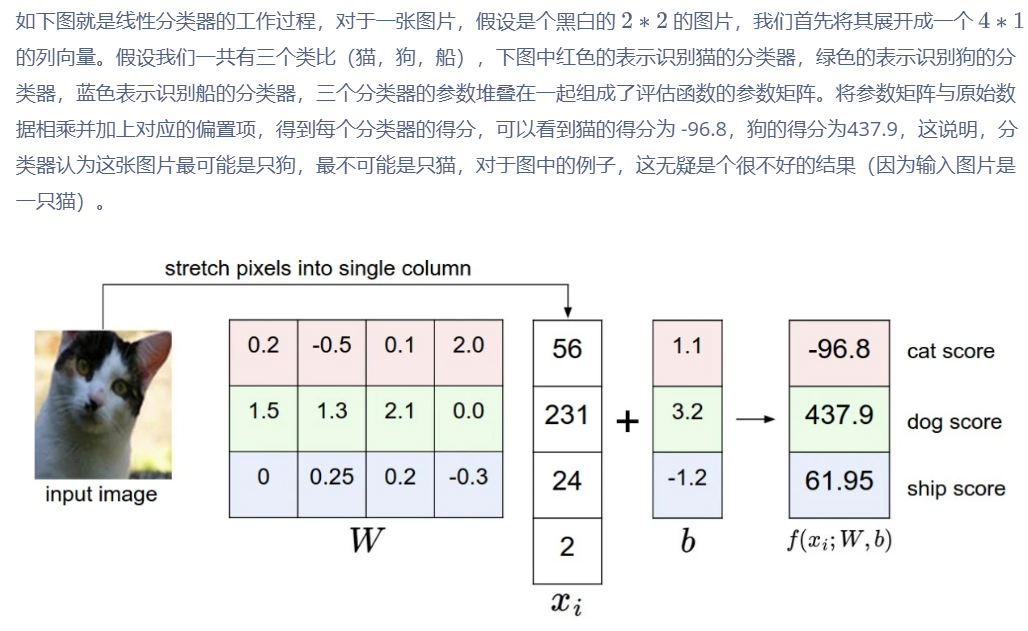
#### 几何解释
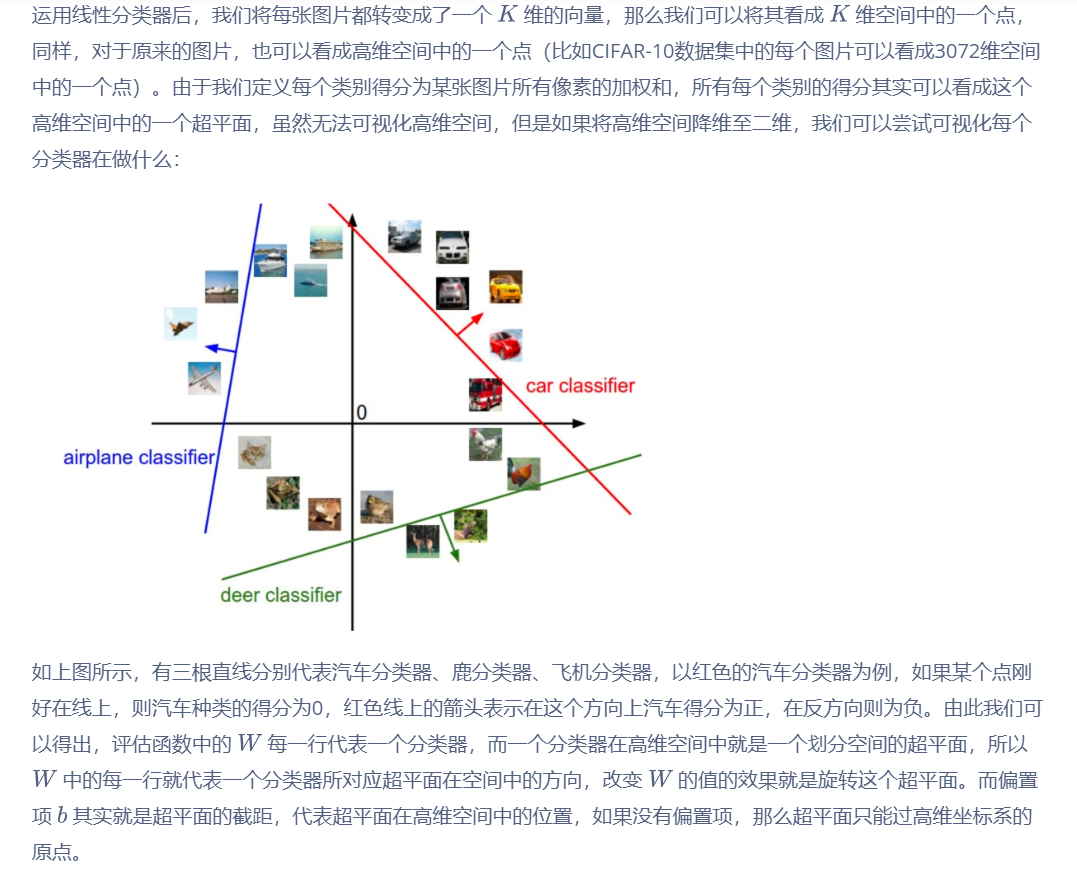
#### 模板匹配
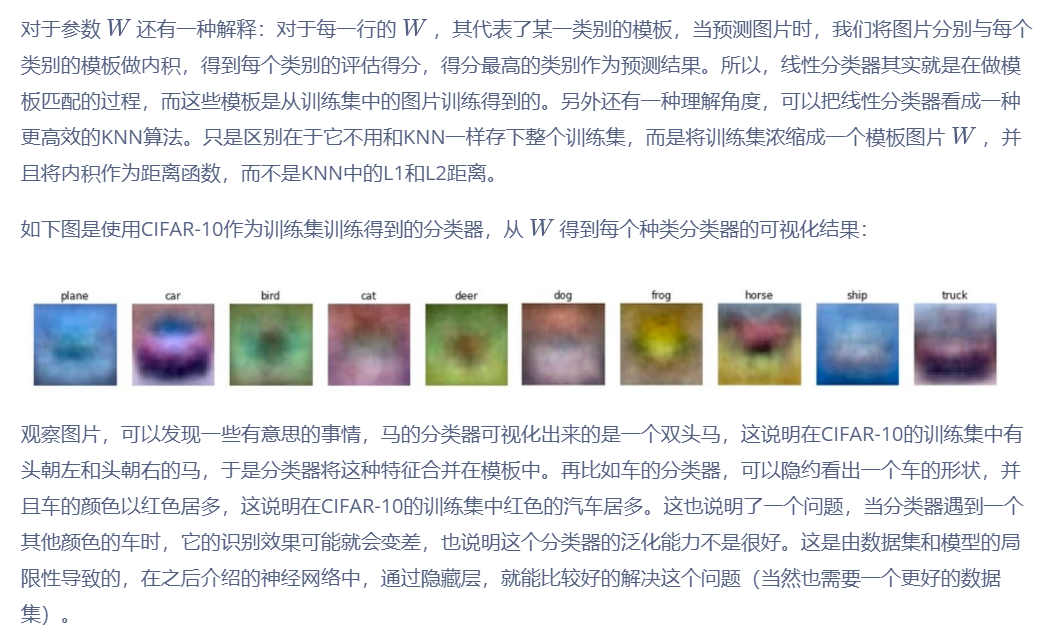
#### 偏置项合并
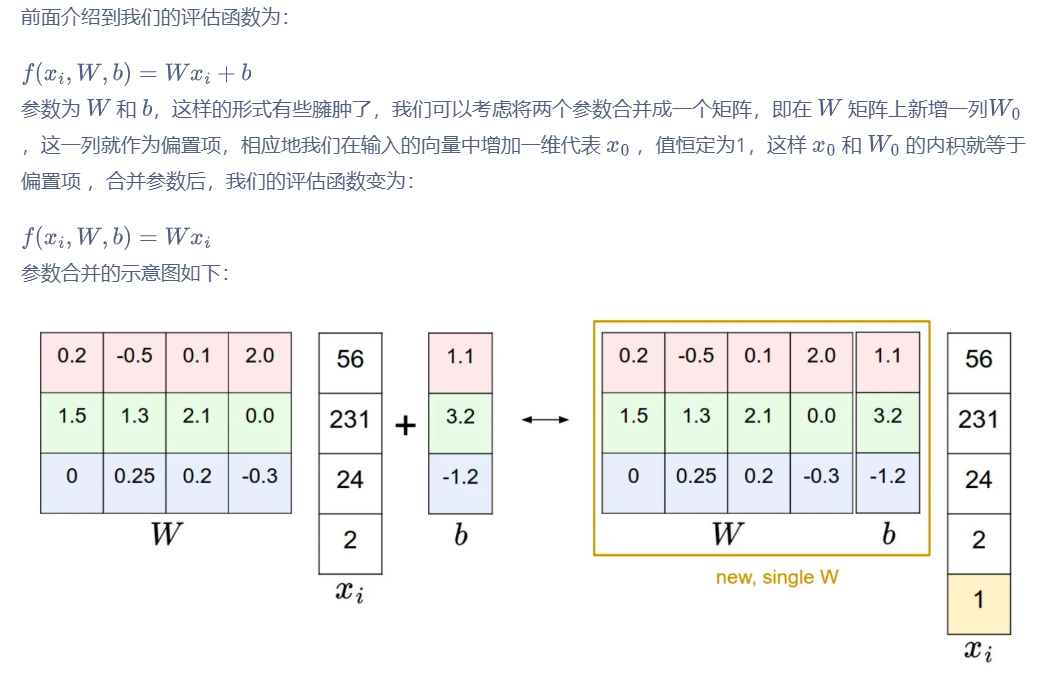
#### 数据预处理
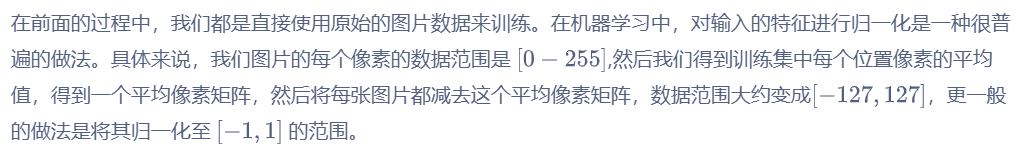
### 损失函数
[SVM和softmax的可视化交互网页](http://vision.stanford.edu/teaching/cs231n-demos/linear-classify/)
### 多分类SVM的损失函数
核心思想：
"正确类别的得分应该比所有错误类别的得分至少高出1个边际"
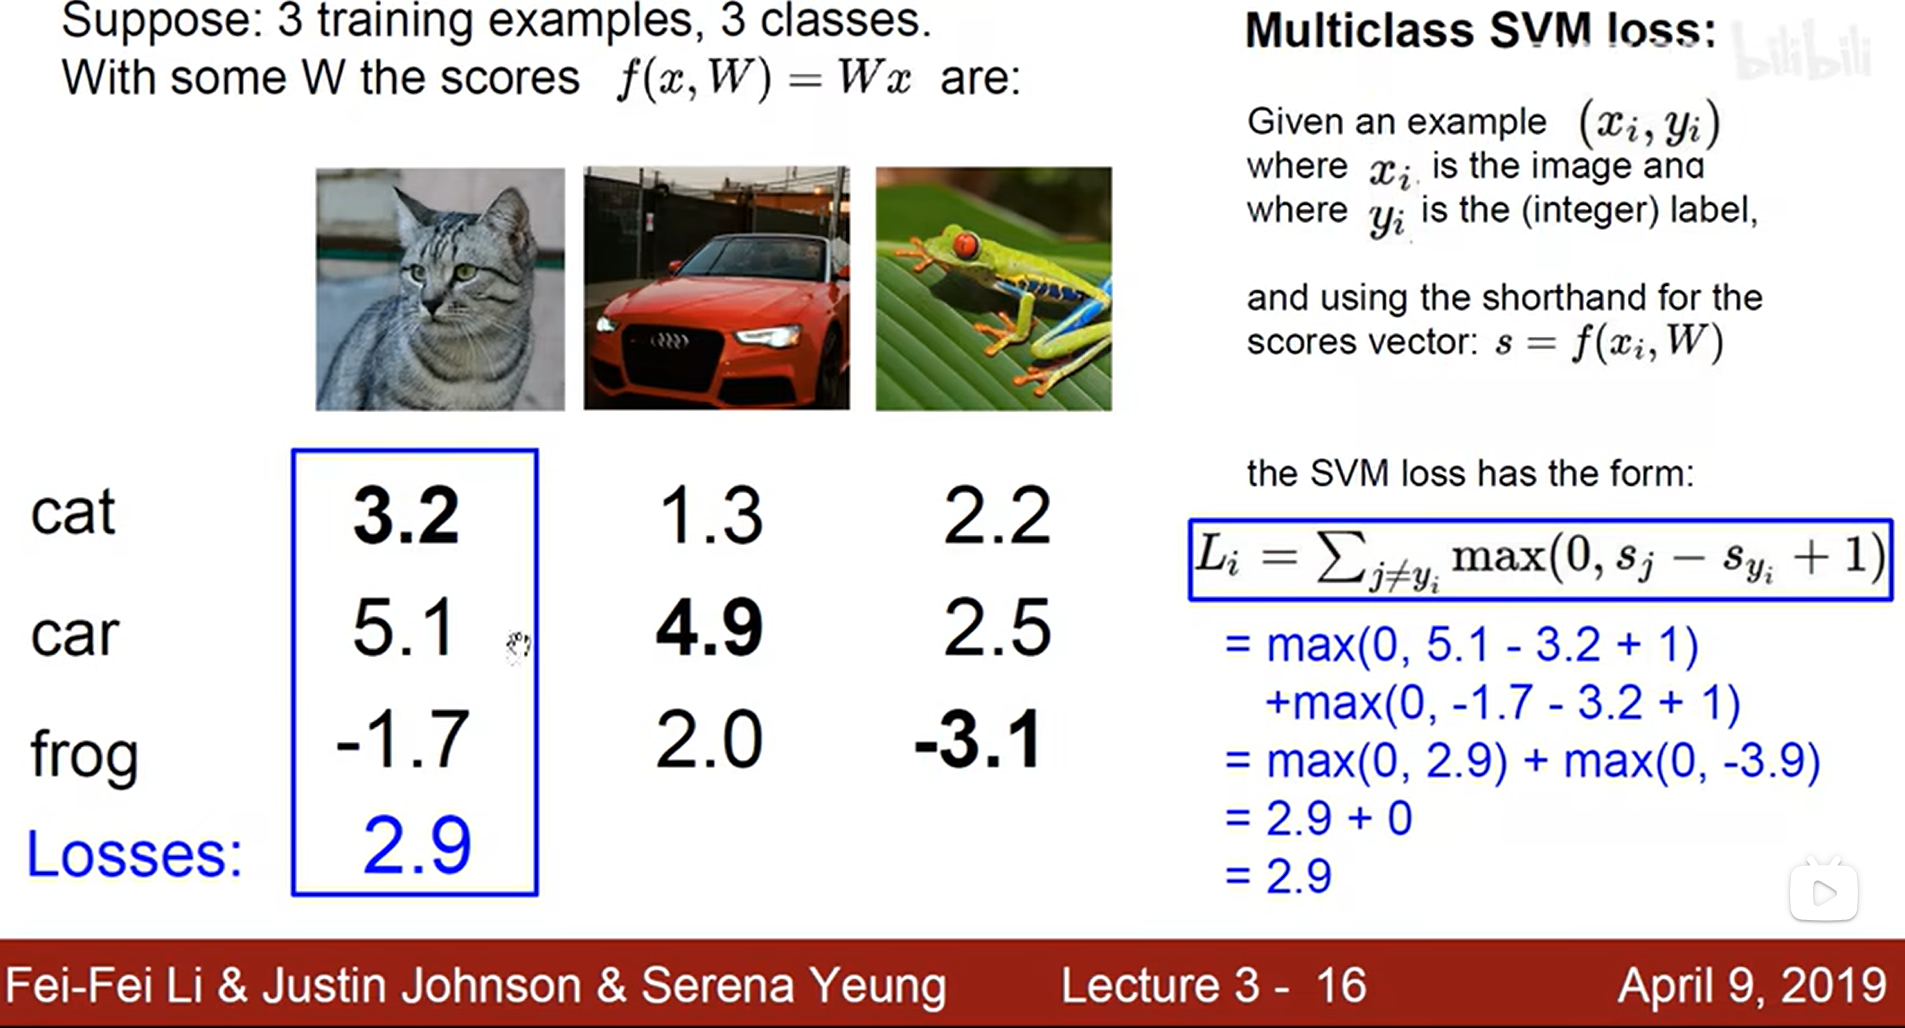
给定数据：
正确类别：y_i = 0（猫）  
得分向量：s = [3.2, 5.1, -1.7]  
s[0] = 3.2（猫的得分）  
s[1] = 5.1（狗的得分）  
s[2] = -1.7（船的得分）  

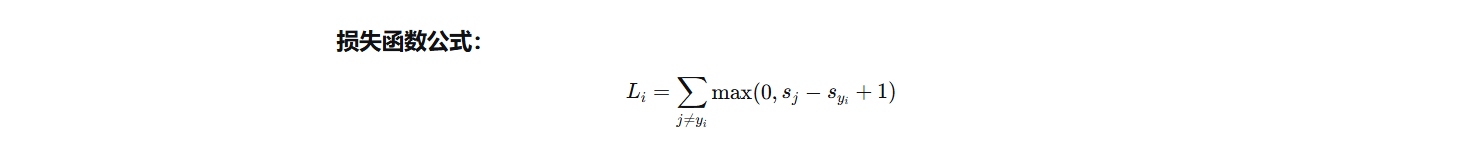  
计算过程：
对于错误类别 j=1（狗）：  
s_j = 5.1（狗的得分）  
s_{y_i} = 3.2（猫的得分）  
s_j - s_{y_i} + 1 = 5.1 - 3.2 + 1 = 2.9  
max(0, 2.9) = 2.9  
对于错误类别 j=2（船）：  
s_j = -1.7（船的得分）  
s_{y_i} = 3.2（猫的得分）  
s_j - s_{y_i} + 1 = -1.7 - 3.2 + 1 = -3.9  
max(0, -3.9) = 0  
总损失： L_i = 2.9 + 0 = 2.9


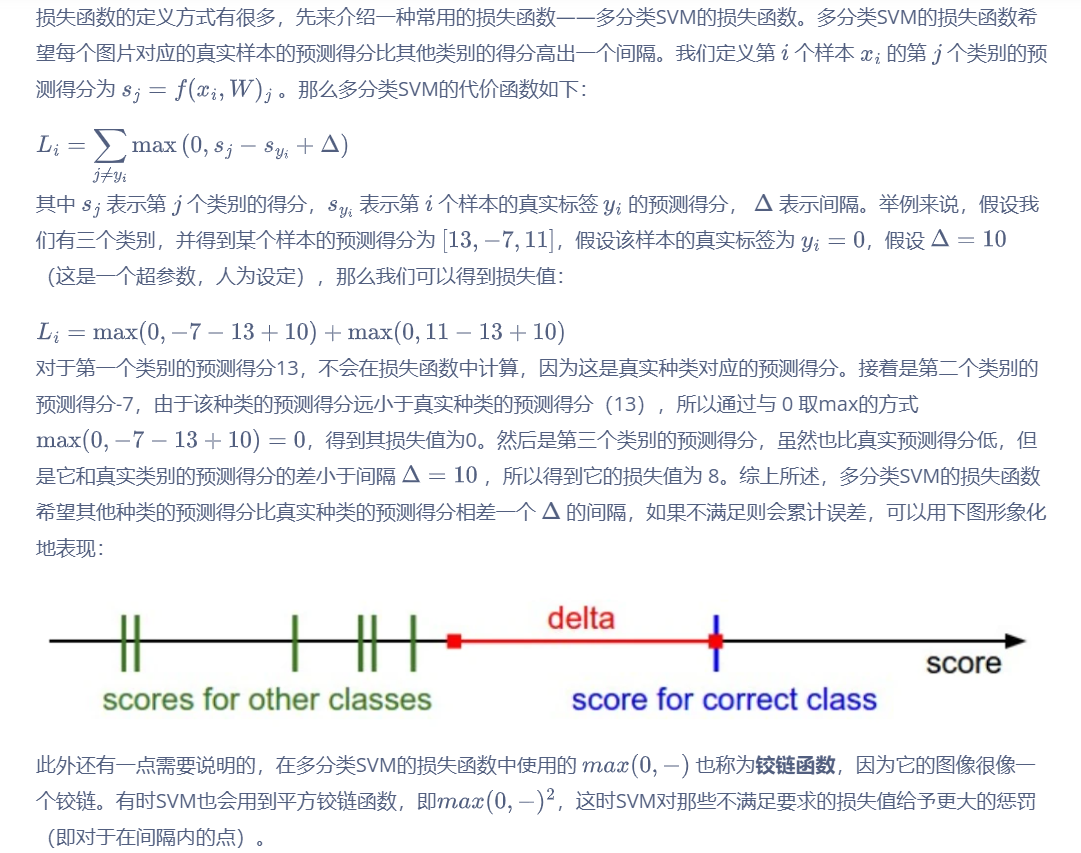


**思考问题**

Q_1：在初始化时，W很小，所有分数s≈0，那么损失是多少?  

解答：(C-1)

当所有分数都接近0时，对于每个样本i，s_{y_i}≈0，s_j≈0。
则对于每个j≠y_i，max(0, s_j - s_{y_i} + 1) = max(0, 0 - 0 + 1) = 1。
所以，对于每个样本，损失为 (C-1) * 1，其中C是类别数（因为j≠y_i的类别有C-1个）

Q_2: 如果对所有的类别(包括j=y_i)求和，会怎样？

解答： 损失函数会加1

如果包括j=y_i，那么求和项中会多一项：max(0, s_{y_i} - s_{y_i} + 1) = max(0,1)=1  
所以，损失会多1，即 L_i = (C-1) * 1 + 1 = C

Q_3: 如果我们使用均值（mean）而不是求和（sum）会怎样？

解答：对原损失函数进行了常数缩放，不影响最终结果

L_i = 1/C-1 ∑ max(0,s_j-s_i+1) ,损失值和梯度变小

Q_4: 如果用平方损失会怎样？

解答：放大梯度，训练不稳定






### Softmax的损失函数（交叉熵损失）
Softmax:把任意实数分数转换成满足概率要求的概率分布  （会放大最高分数的优势）  
过程：  
1. 指数化（确保非负）
2. 归一化（确保和为1）
数学定义：  
P(y=k∣x)= e^s_k / ∑_j e ^ s_j
- s_k是第k个类别的原始分数
- 分母是所有类别分数的指数和
- P(y=k∣x) 是样本x属于类别k的概率
​

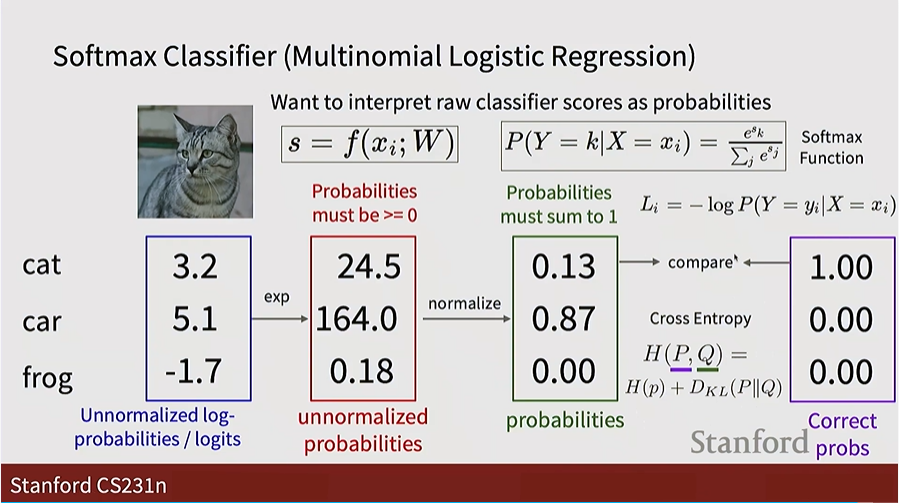

**损失函数是负对数的解释：**
1. 为什么不直接使用概率：
梯度会很小：导数 = -1 ，梯度恒定，不利于学习。  
而用负对数：梯度 = - 1 / p_(y) ,当概率小时梯度大，加速学习。
真实类别和错误类别?
2. 信息论角度：交叉熵
### 交叉熵损失函数（Cross-Entropy Loss）
交叉熵=−∑(真实概率×log(预测概率))  
**熵** ： 最小平均编码长度  
以计算机中的二进制举例：【位数=编码长度】  
选择8种药其中一种，概率为1/8，至少需要三位二进制数字进行编码（2**3=8）  
二进制数字上的每一位数都只能有两种情况：0或1 如果一个随机事件只存在两种可能那就只需要一位二进制数字  
**最小平均编码长度 = 编码长度的期望**
随机事件用期望反映平均值的大小


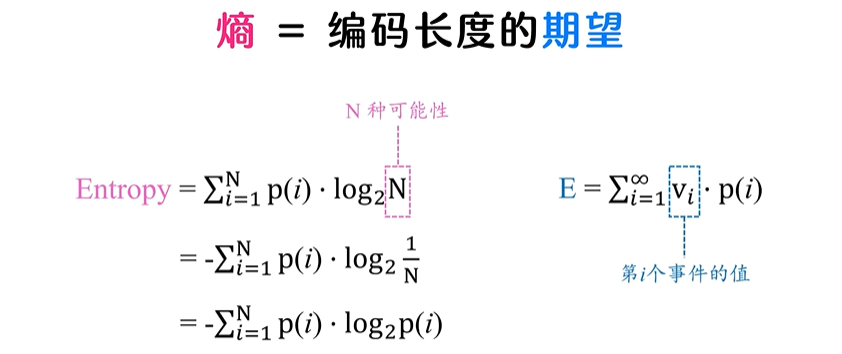

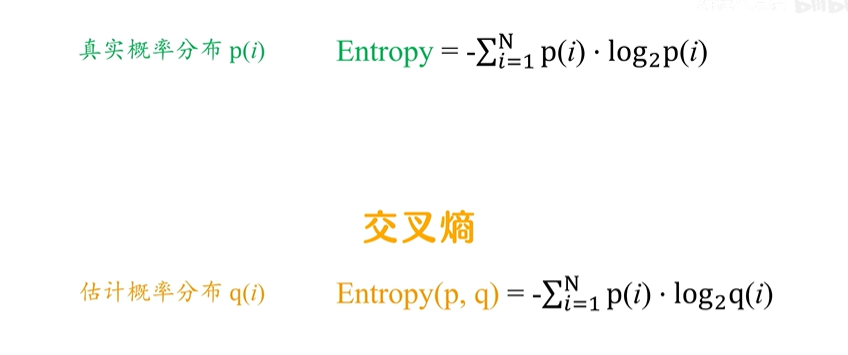

p(i)表示 样本真实标签  q(i)表示 模型预测结果

**相对熵（KL）：**
是一种量化两种概率分布P和Q之间差异的方式  
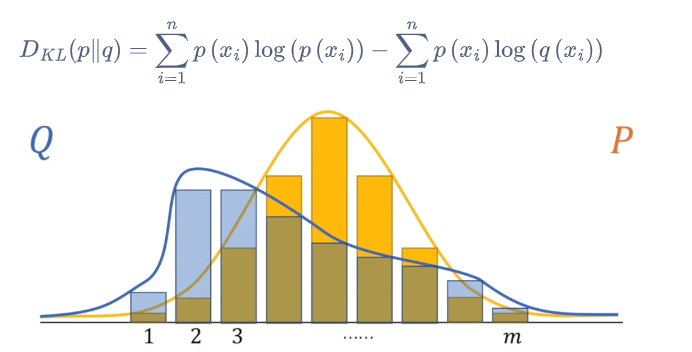


真实分布：独热编码（one-hot）  
[1 , 0 , 0] , [0 , 1 , 0] , [0 , 0 , 1]

**思考问题**

Q_1：在初始化时，W很小，所有分数s≈0，那么损失是多少?  

解答：logC

当所有分数都接近0时，对于每个样本s_j≈0。
对于所有类别指数化求和：∑ e ——> C (类别数) 
所以，对于每个样本，损失为 -log(1/C) = logC

Q_2: 如果我们使用均值（mean）而不是求和（sum）会怎样？

解答：概率不再归一化，大于1 ； 在原损失函数上加上常数偏移，损失值整体偏移，但梯度不变

L_i=−log(C⋅P(y_i))=−logP(y_i)−logC


#### **softmax**损失函数的梯度公式推导
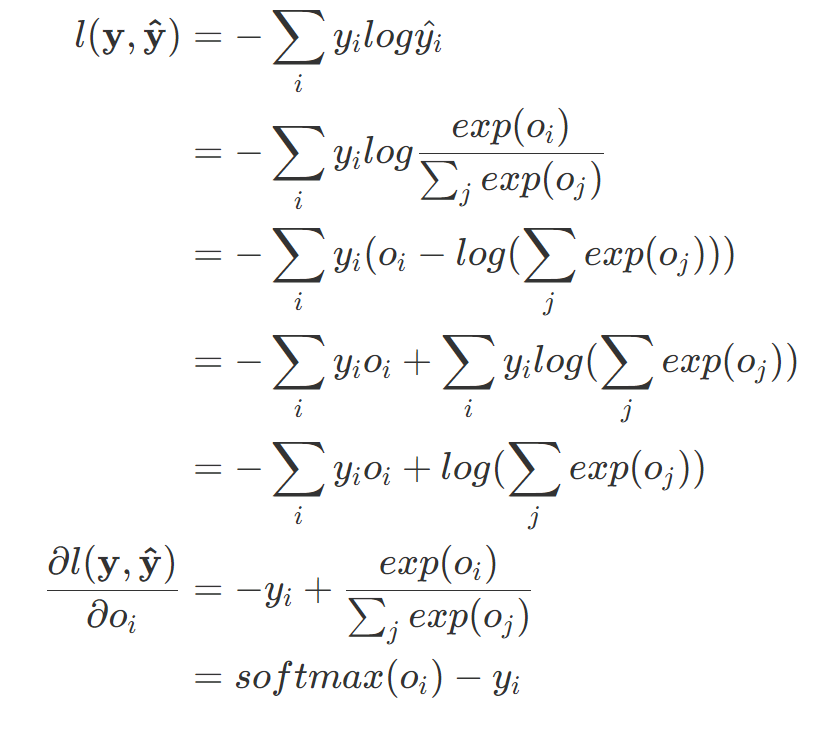
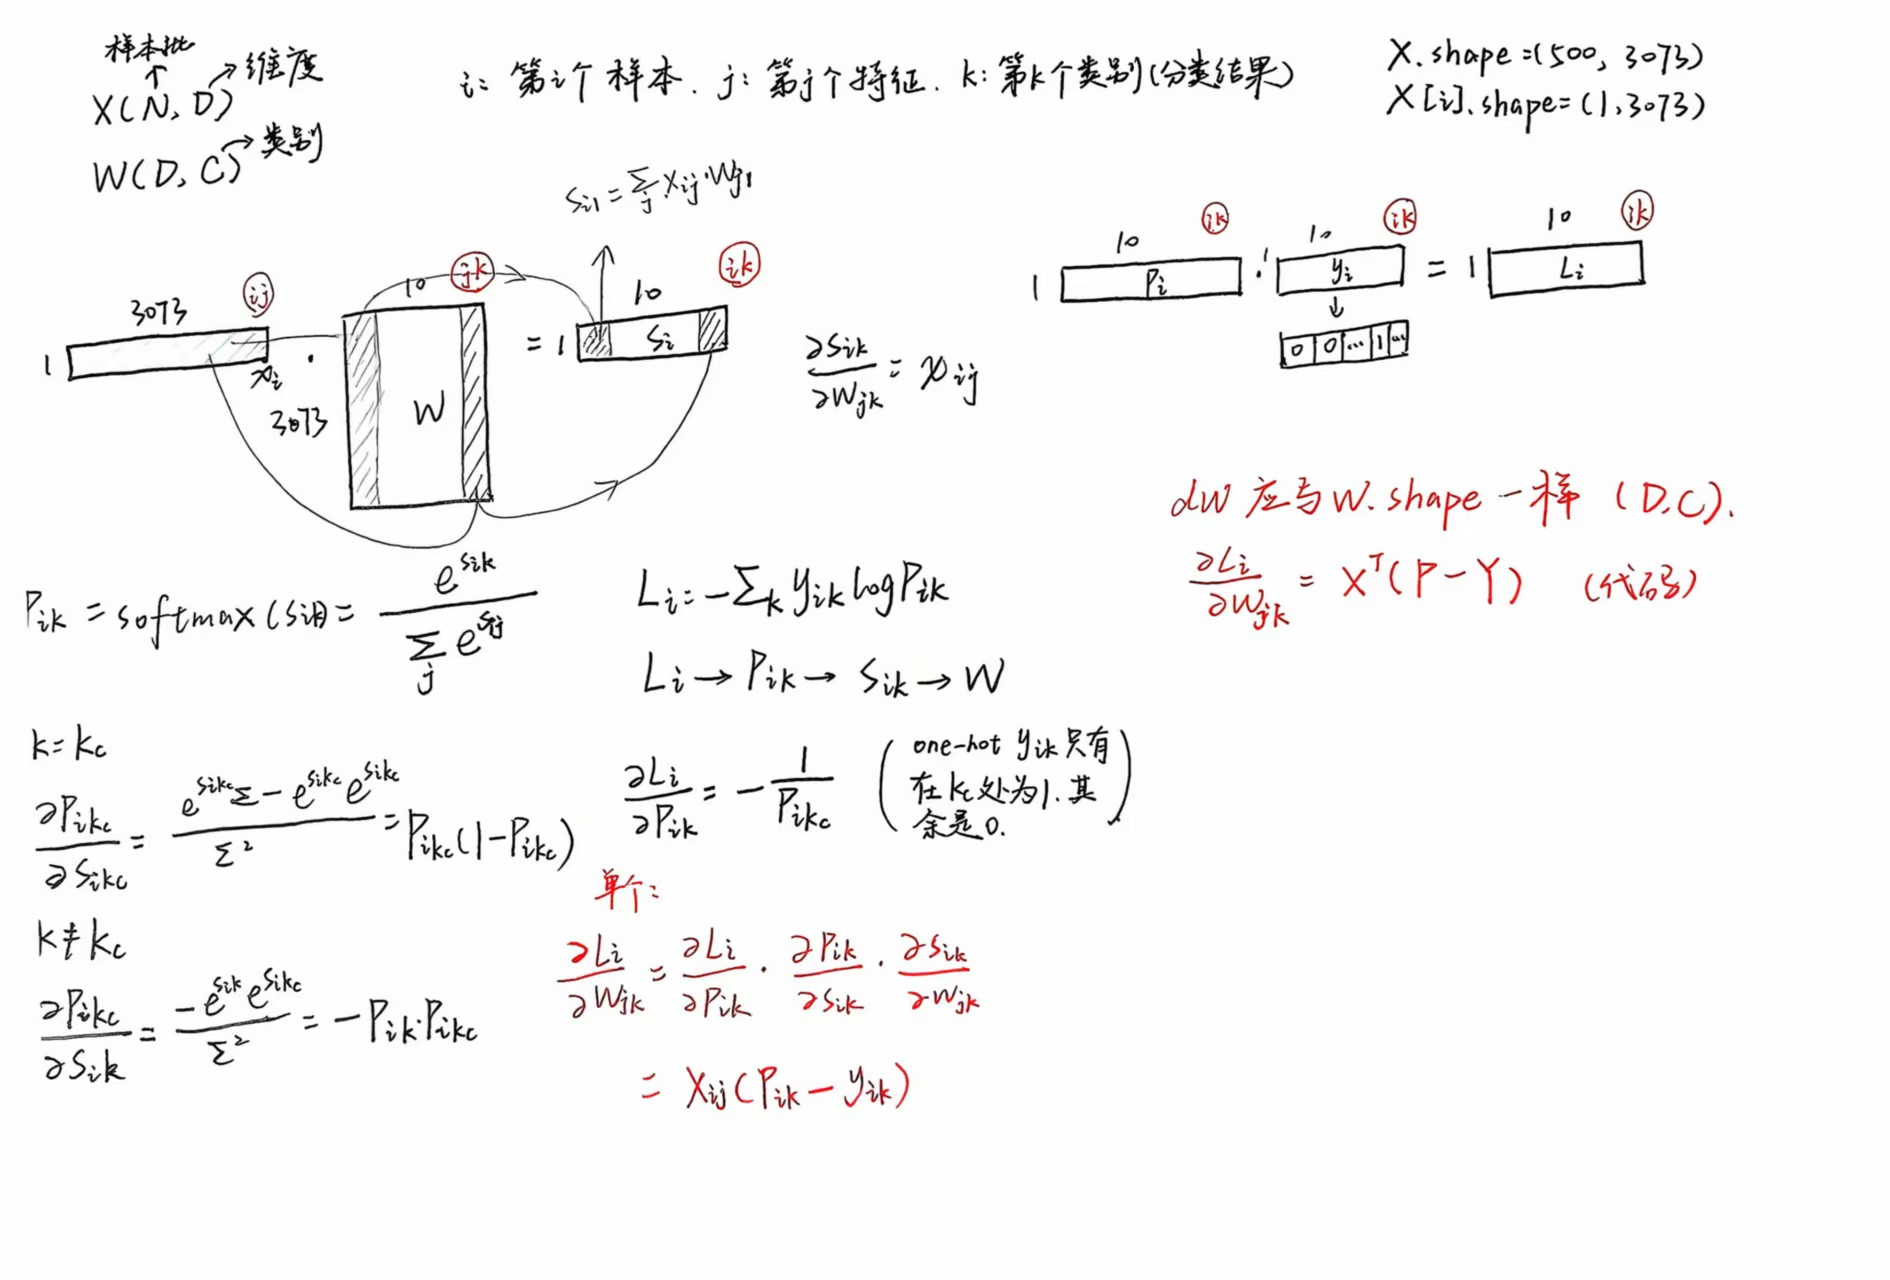


#### 逻辑回归(logistic Regression)
sigmoid是二分类逻辑回归(logistic function)，softmax是多项逻辑回归  
logistic function :将任意实数映射到（0.1）区间上
标准形式（数学定义）是：  
σ(z) = 1 / (1 + e **(-z))
- 𝑧是输入值（通常是线性组合：𝑧=𝑤0+𝑤1𝑥1+𝑤2𝑥2+...）
- 𝑒是自然常数（约等于2.718）
- 𝜎(𝑧)输出值在 (0, 1) 之间


### 正则化（regularization）
目的：防止过拟合  
正则化只是对权重进行的，与训练数据无关
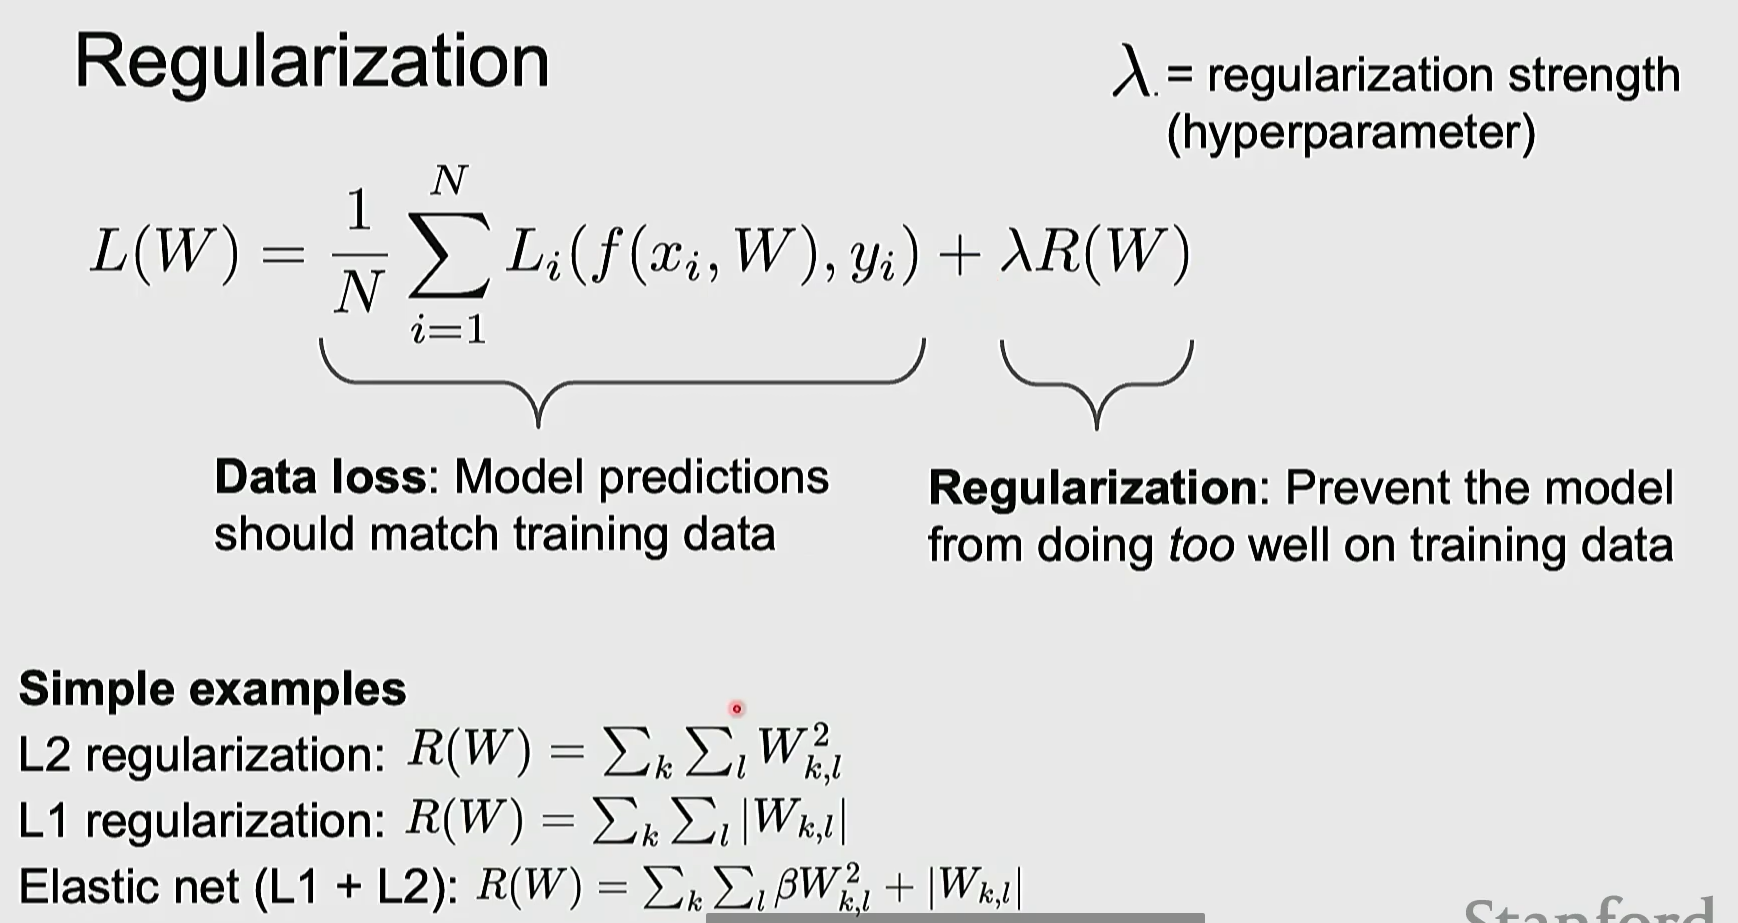
现在的目标：  
最小化： Loss(Data | w) + λ * Regularization(w)  

L2 正则化 - Ridge 回归
惩罚项：所有模型参数平方和。

公式：Regularization(w) = ||w||₂² = w₁² + w₂² + ... + wₙ²

完整目标函数：
Minimize: Loss(Data | w) + λ * (w₁² + w₂² + ... + wₙ²)  

L1 正则化 - Lasso 回归
惩罚项：所有模型参数绝对值之和。

公式：Regularization(w) = ||w||₁ = |w₁| + |w₂| + ... + |wₙ|

完整目标函数：
Minimize: Loss(Data | w) + λ * (|w₁| + |w₂| + ... + |wₙ|)

### Optimization优化
1. 随机搜索 ： 准确率低    
2. 跟随梯度 ： 计算出一个向量，保证在数学上朝着这个方向是当前下降最快的。这一向量称作损失函数的梯度 （对于一个一维的函数，梯度就是其斜率，而对于一个多维的函数，梯度是一个向量，每一维度就是对应属性在多维函数中的偏导数）  

1. 使用有限差分计算梯度

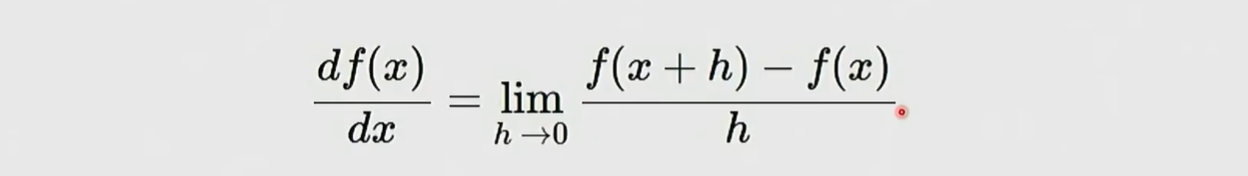

任一方向的斜率就是将梯度与方向做点积，最陡方向梯度是负梯度

以下是实现：

In [1]:
def eval_numerical_gradient(f, x):
  """
  a naive implementation of numerical gradient of f at x
  - f should be a function that takes a single argument
  - x is the point (numpy array) to evaluate the gradient at
  """
 
  fx = f(x) # evaluate function value at original point
  grad = np.zeros(x.shape)
  h = 0.00001
 
  # iterate over all indexes in x
  it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
  while not it.finished:
 
    # evaluate function at x+h
    ix = it.multi_index
    old_value = x[ix]
    x[ix] = old_value + h # increment by h
    fxh = f(x) # evalute f(x + h)
    x[ix] = old_value # restore to previous value (very important!)
 
    # compute the partial derivative
    grad[ix] = (fxh - fx) / h # the slope
    it.iternext() # step to next dimension
 
  return grad

4. 梯度下降法 ：  
计算损失函数的梯度，重复评估梯度然后执行参数更新的过程称为梯度下降

In [ ]:
# Vanilla Gradient Descent
 
while True:
  weights_grad = evaluate_gradient(loss_fun, data, weights)
  weights += - step_size * weights_grad # perform parameter update

梯度下降最流行的变体：**Stochastic Gradient Descent（SGD）** 随机梯度下降


In [ ]:
# Vanilla Minibatch Gradient Descent
 
while True:
  data_batch = sample_training_data(data, 256) # sample 256 examples
  weights_grad = evaluate_gradient(loss_fun, data_batch, weights)
  weights += - step_size * weights_grad # perform parameter update

局部极小值和鞍点问题 ： SGD + Momentum(动量)
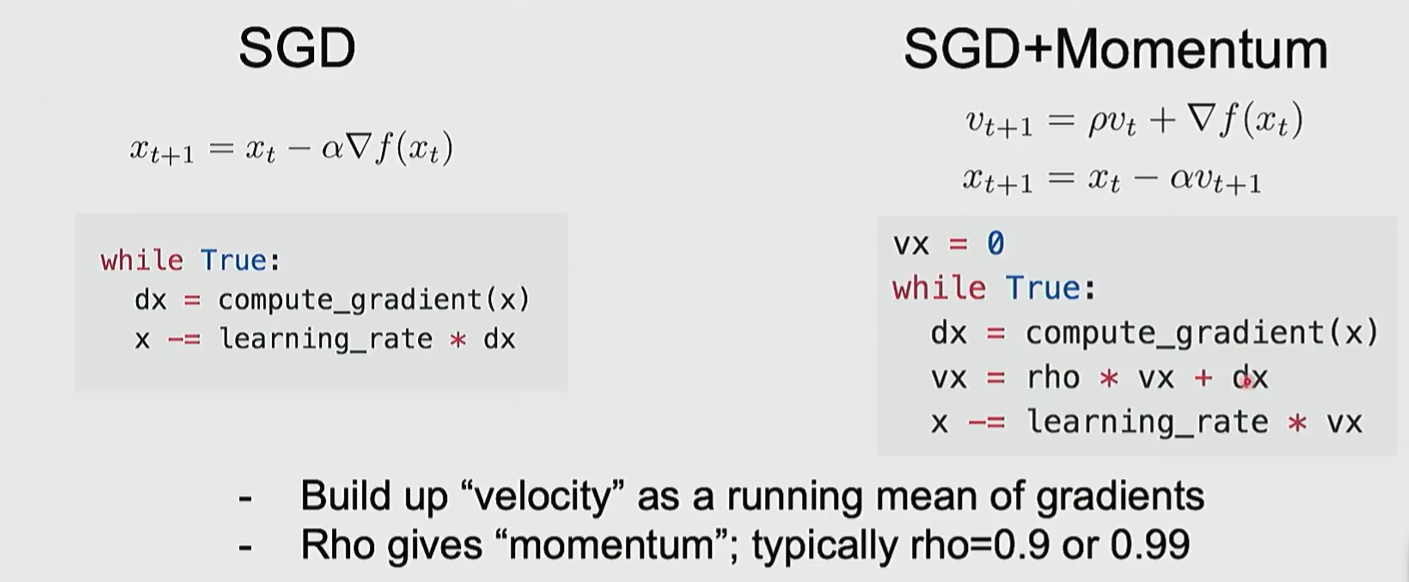

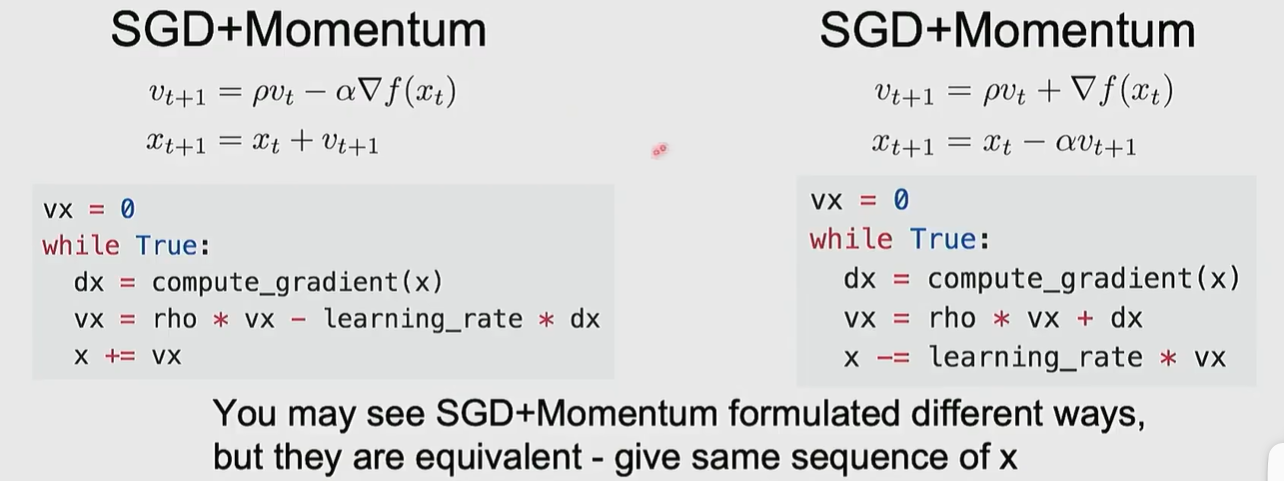

##### Adam(almost Optimizers)

先空着，后续补上，还有：

+Momentum，adam,Rmsrop,AdaGrad, Adam,Learning rate schedules的推理
还有激活函数

以及two_layer_net.ipynb里的问题


## 神经网络

克服线性分类器的局限性： 一种方法是特征变化(feature transform):

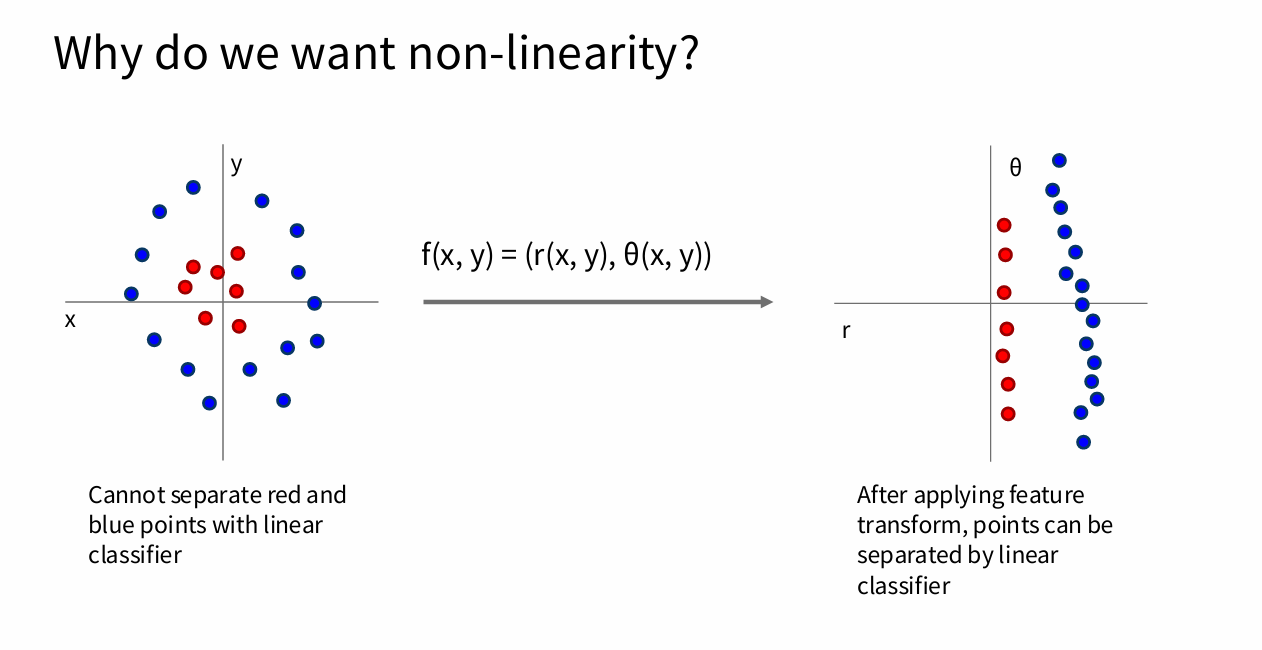

一种简单的特征变化是颜色直方图(color histogram), 通过不同颜色的出现频率分类, 抛弃空间信息

另一种方法是定向梯度方法的直方图(Histogram of Oriented Gradients)(HoG)，通过捕捉图像中局部区域的边缘方向信息来描述物体的形状和轮廓, 抛弃颜色信息

这些方法的本质都是提取特征并调整特征以获得更高的得分

神经网络的本质也类似, 只不过它有多层，更准确地称为“全连接网络”，有时也称为“多层感知器”(MLP)（在实际操作中，我们通常还会在每一层加入可学习的偏置，可以这么表示：

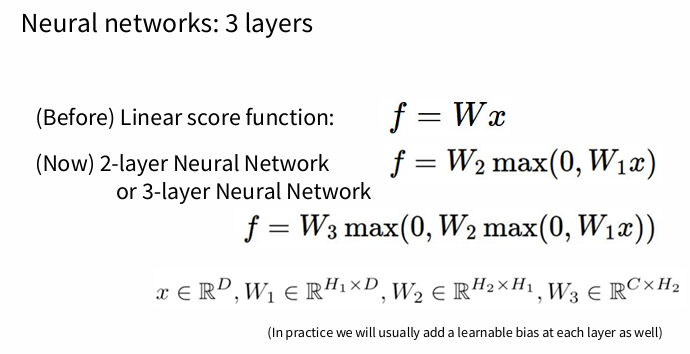

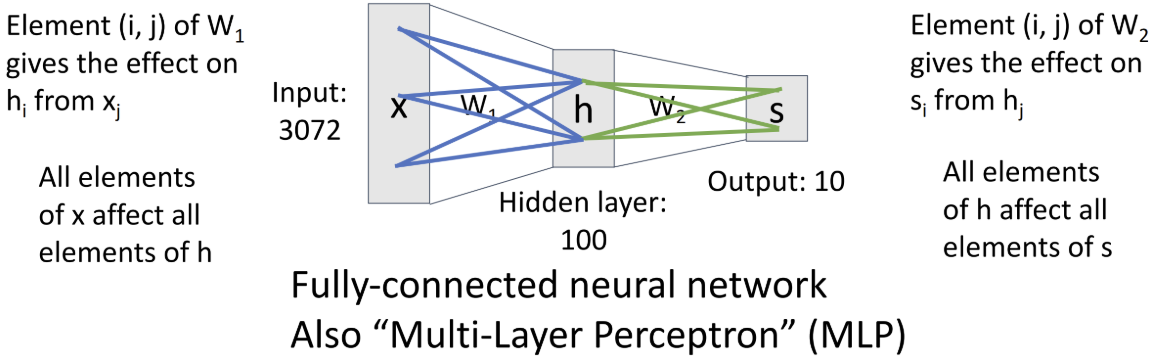



### 

为什么在f中要取 max(0,W1)? 这是激活函数(activation function)的一种ReLu,  激活函数是非线性函数, 如果不施加的话我们得到的还是一个线性分类器 f=W2W1x = Wx 

### 激活函数
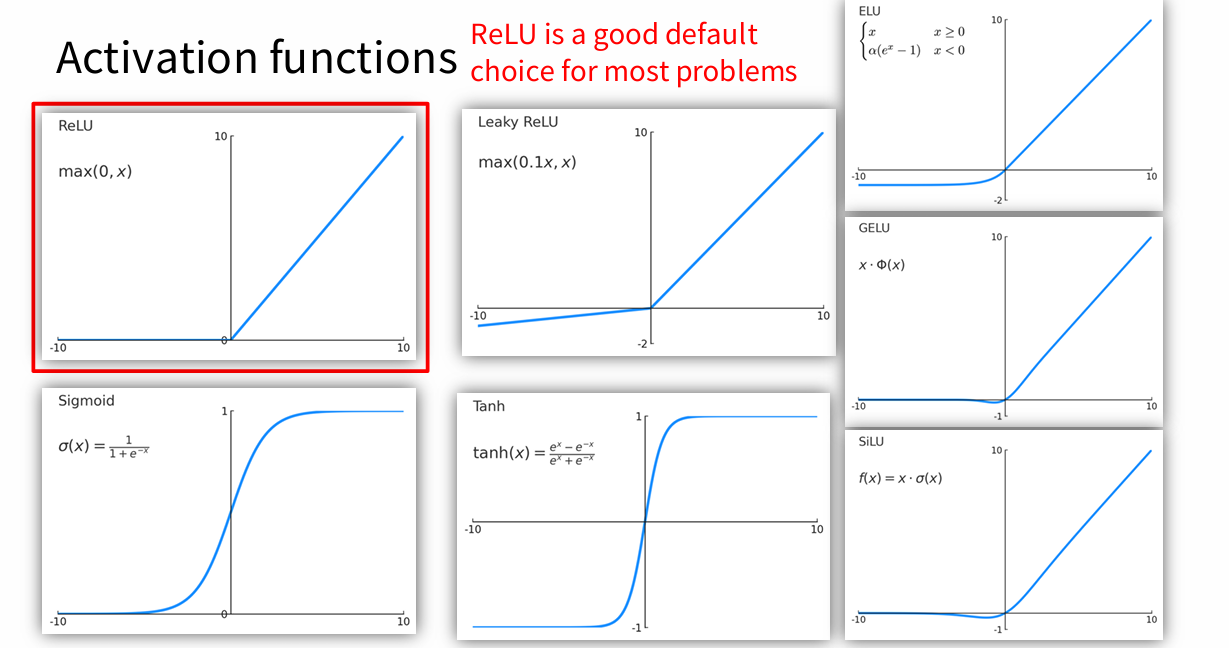

满足三个条件：

1. 连续可导函数
2. 定义域R,能映射所有实数
3. 单调递增曲线，非线性变换，不改变响应状态

##### sigmoid 激活函数

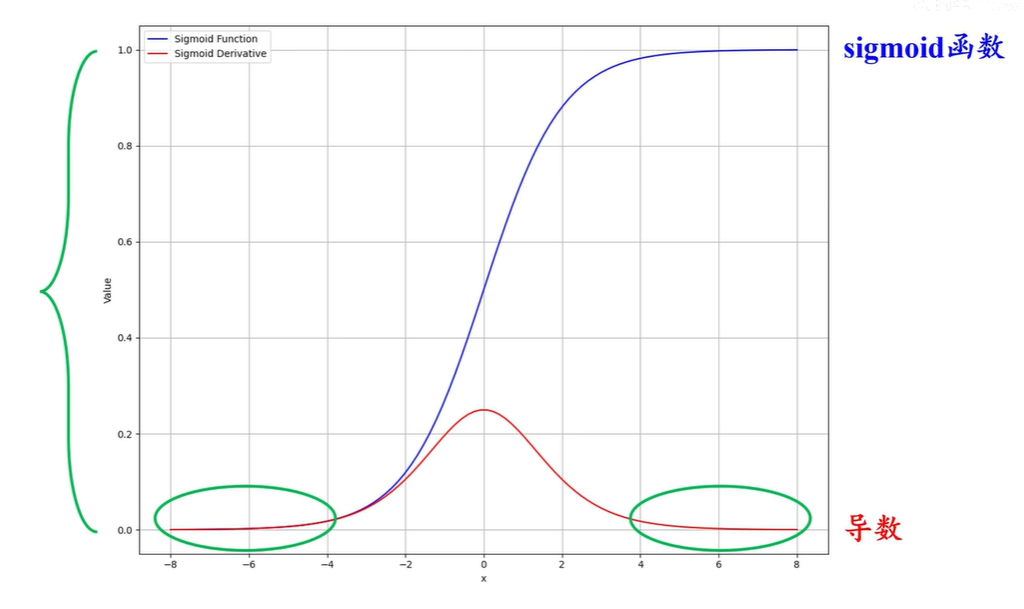

是饱和函数：正负无穷梯度为0，在反向传播时越浅层的梯度值越接近0，出现梯度消失，
是非零均值函数：反向传播时，损失函数对激活函数的求导会使W1，W2的梯度
符号始终一致，被强制的同时正向或反向更新， 使收敛更慢



##### tanh函数

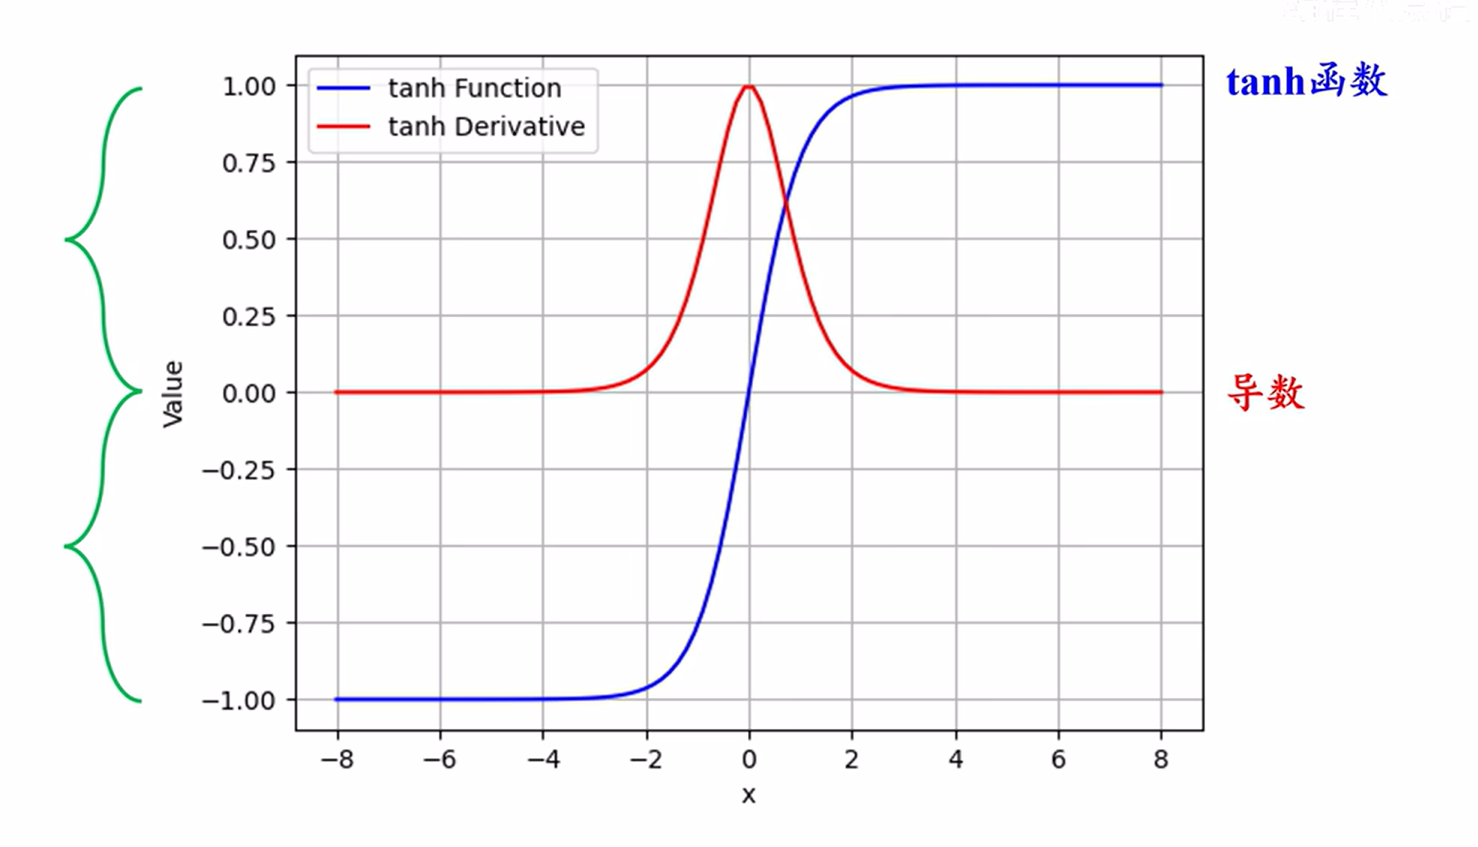

不是非零均值函数：解决不易收敛问题，但依旧存在梯度饱和，梯度消失现象

##### ReLU函数

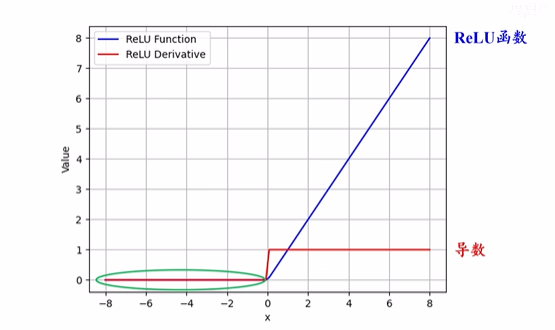

计算简单快速收敛，非饱和避免梯度消失


对于ReLU的优化函数，后续补上

#### 前向计算

In [ ]:
f = lambda x: 1.0/(1.0 + np.exp(-x))
x = np.random.randa(3,1)
h1 = f(np.dot(W1,x)+b1)
h2 = f(np.dot(W2,h1)+b2)
out = np.dot(W3,h2)+b3

#### 反向传播

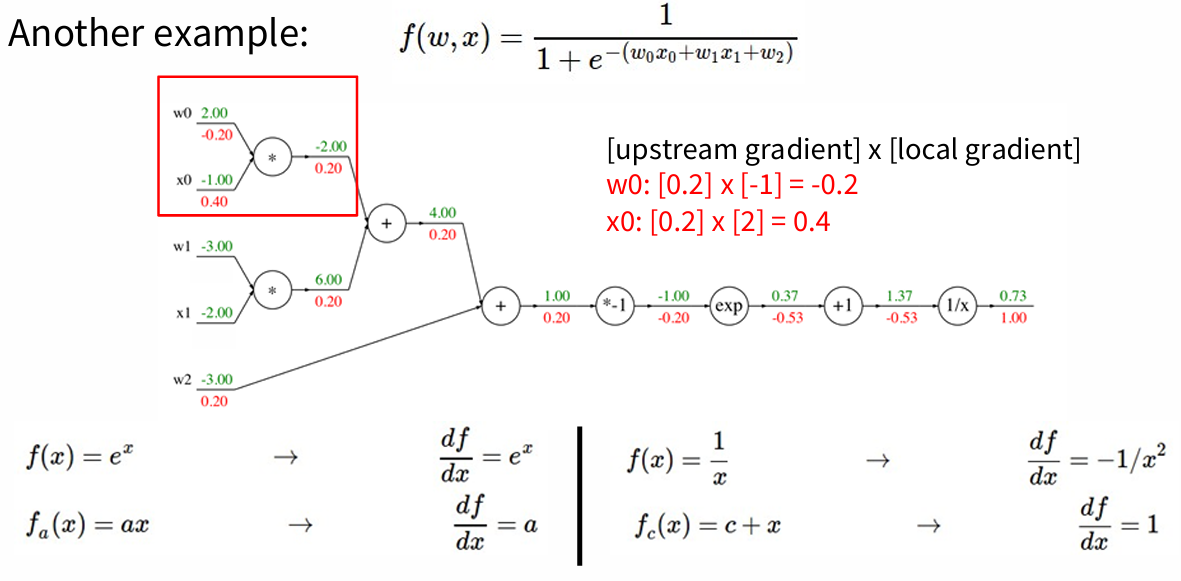

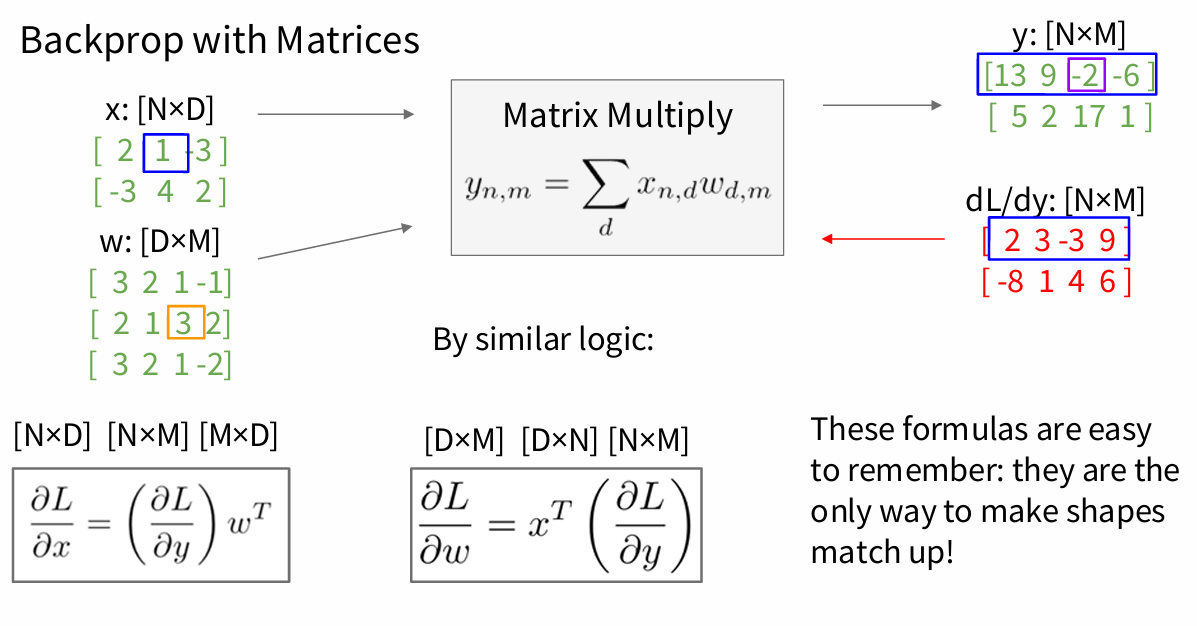

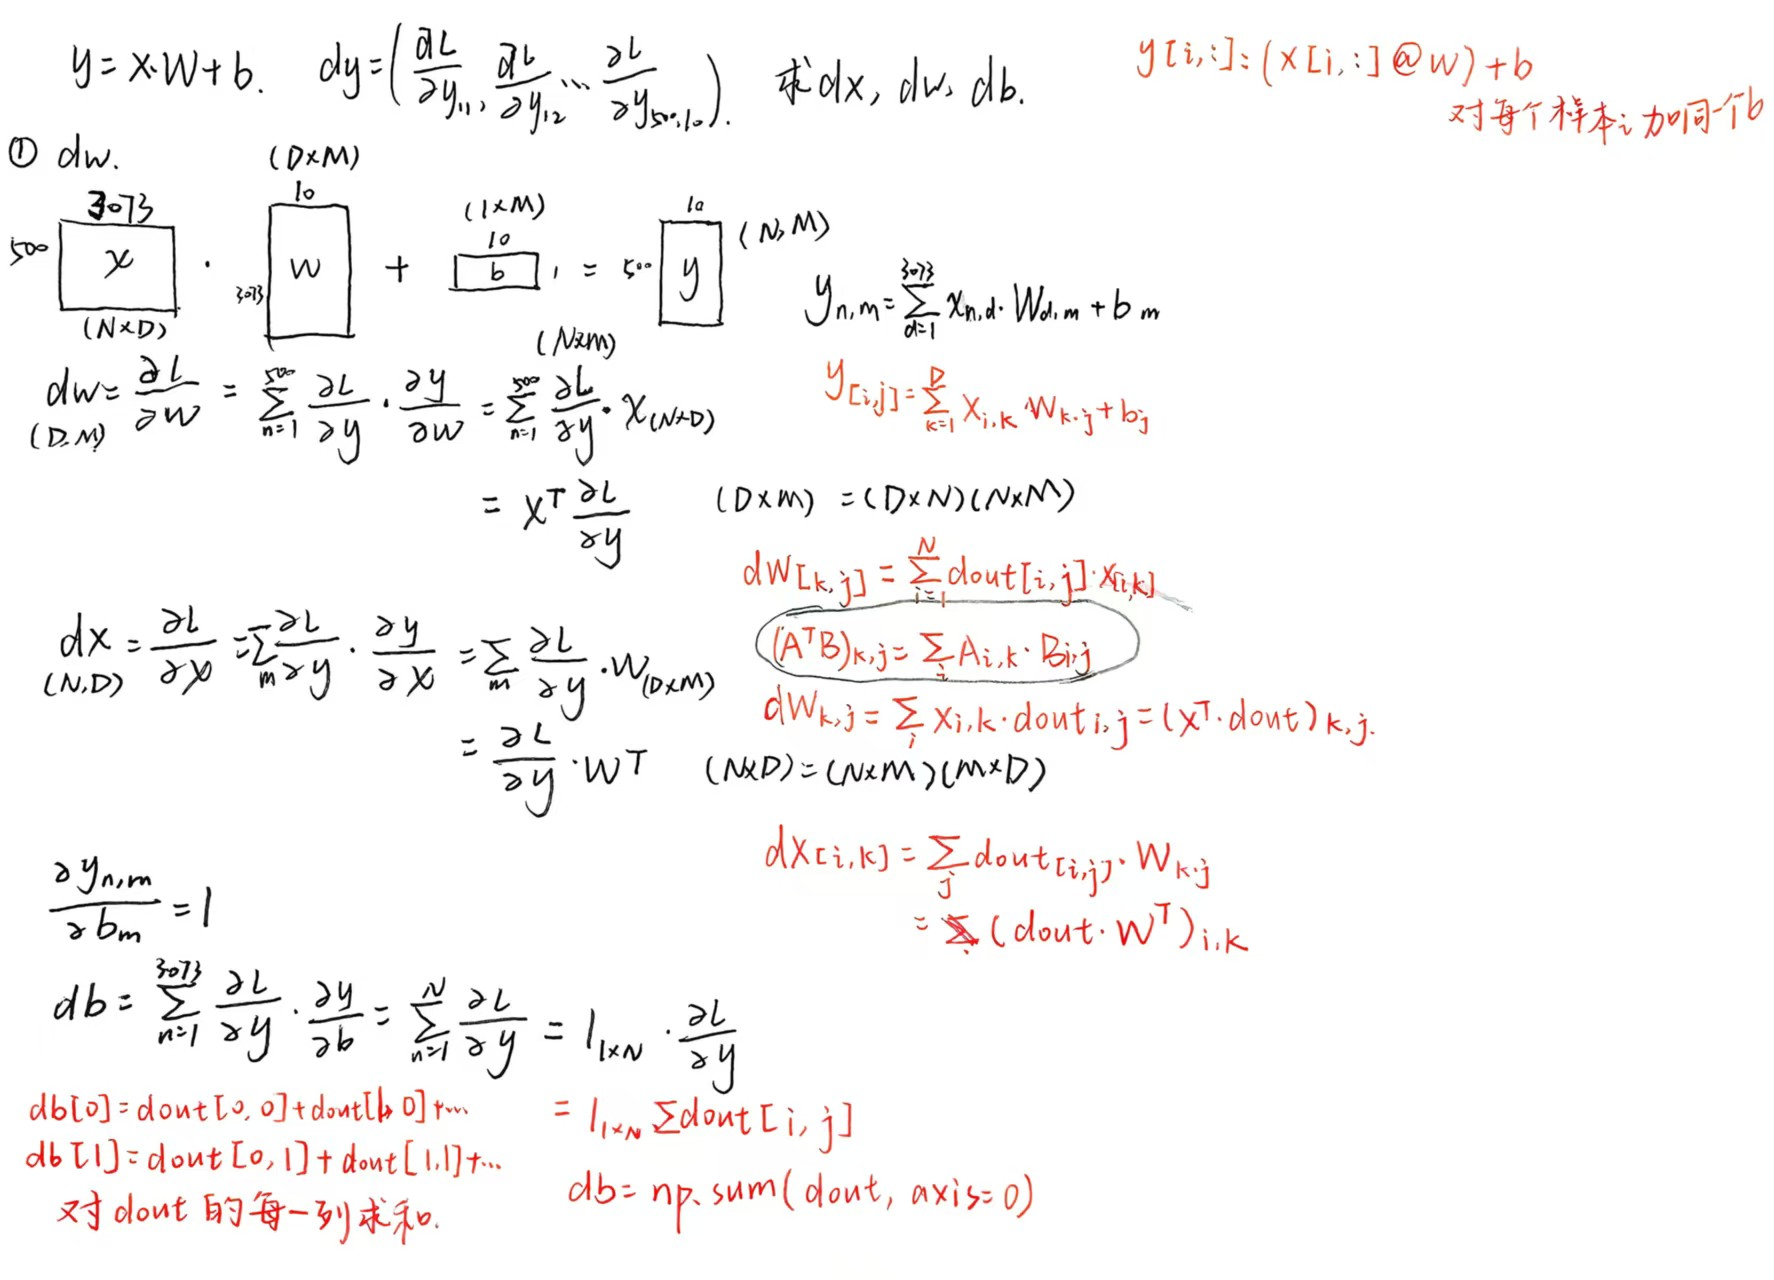

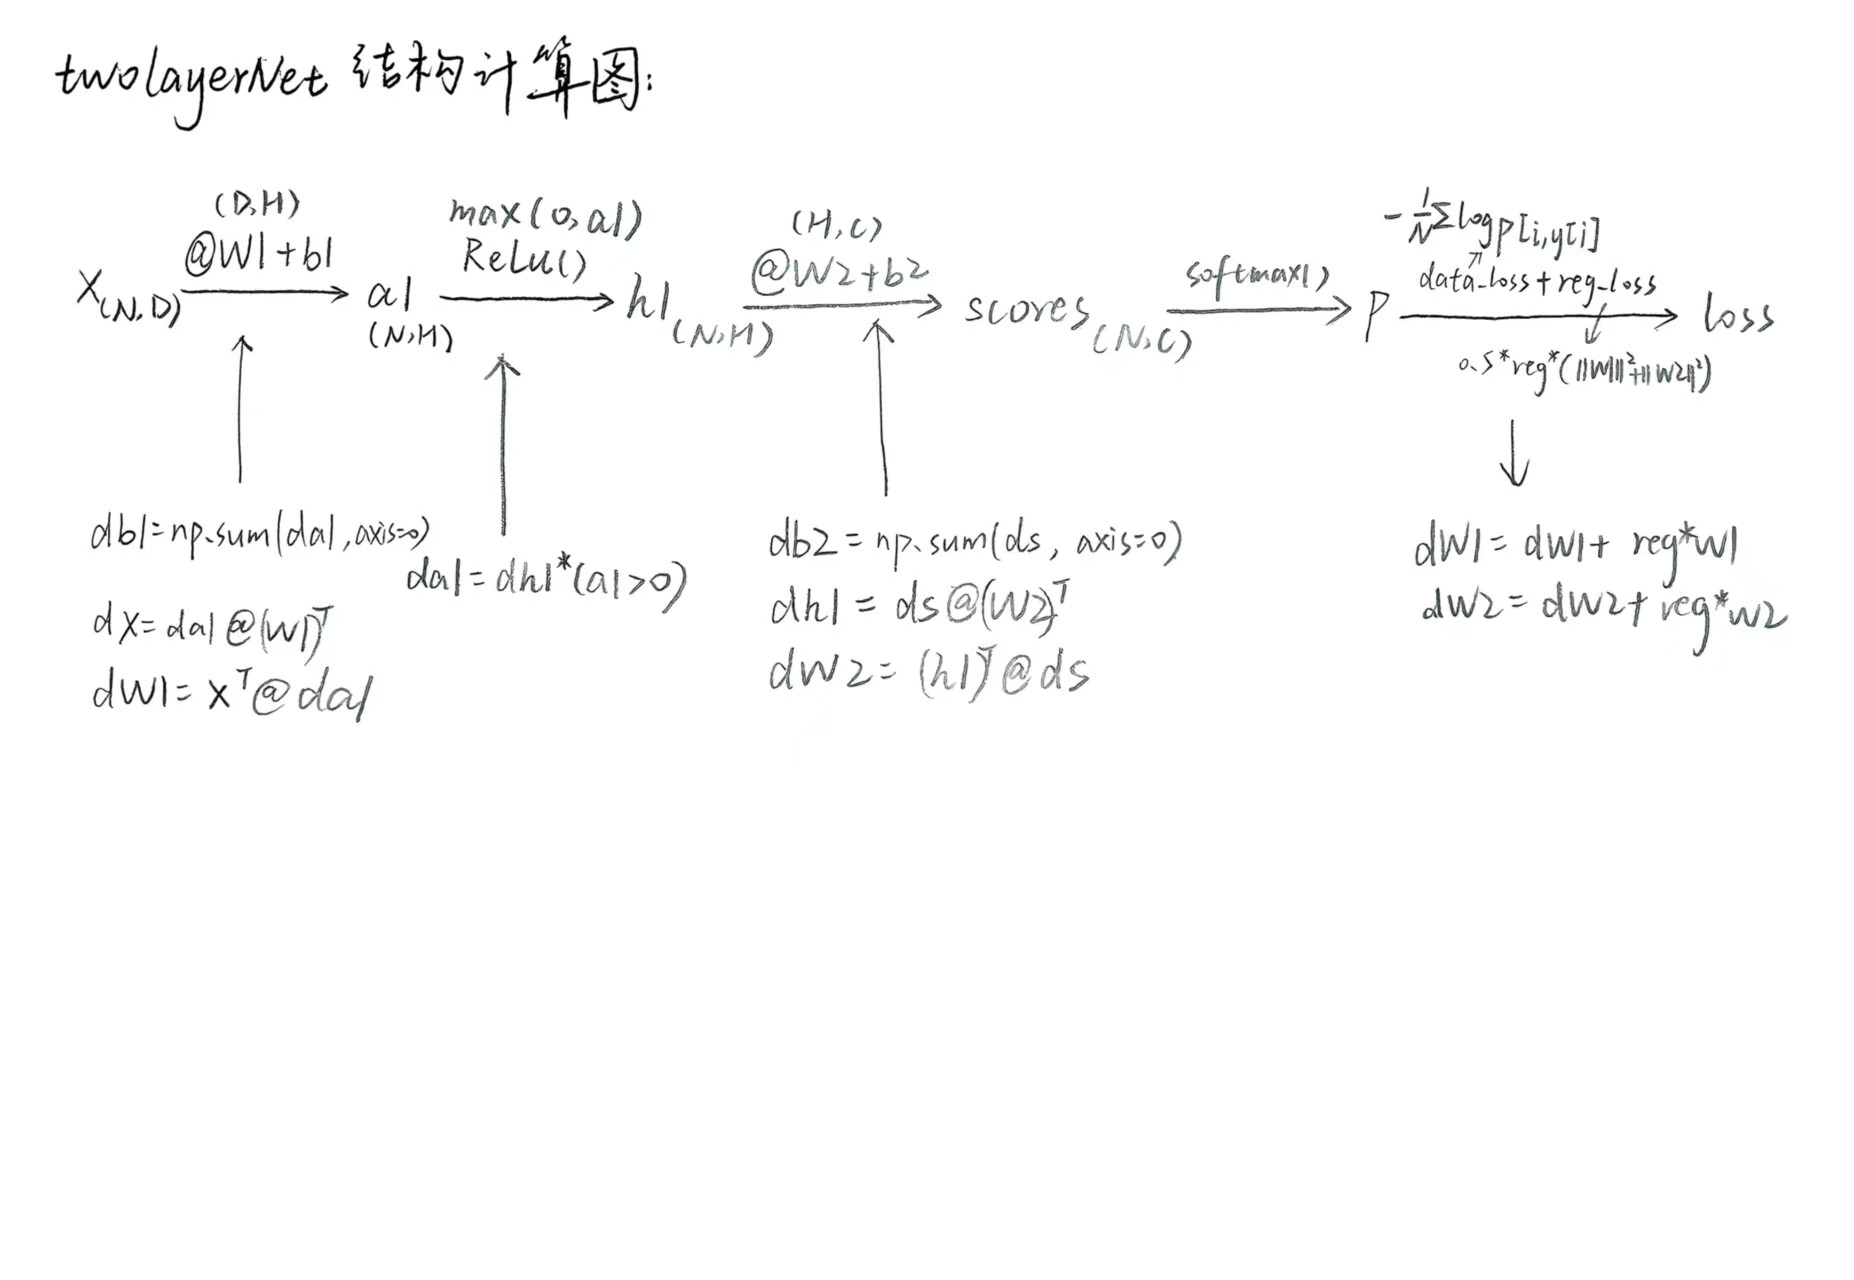